### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [80]:
from imblearn.over_sampling import RandomOverSampler

### Step 2: Load Dataset

In [24]:
df = pd.read_csv('./data/framingham.csv')

In [25]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [26]:
df.shape

(4240, 16)

### Step 3: Exploaring Data

In [27]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [29]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

TenYearCHD
0    3101
1     557
Name: count, dtype: int64


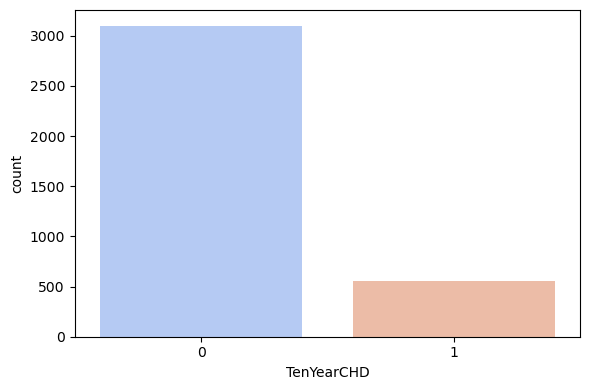

In [52]:
plt.figure(figsize=(6, 4))
sns.countplot(x='TenYearCHD', data=df, palette='coolwarm')
print(df['TenYearCHD'].value_counts())
plt.tight_layout()

### Step 4: Feature Engineering

Handling Missing Values

In [31]:
df.dropna(axis=0, ignore_index=True, inplace=True)

Normalization

In [34]:
scaler = StandardScaler()

In [42]:
for col in ['age', 'education', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']:
    df[col] = scaler.fit_transform(df[[col]])

<Axes: >

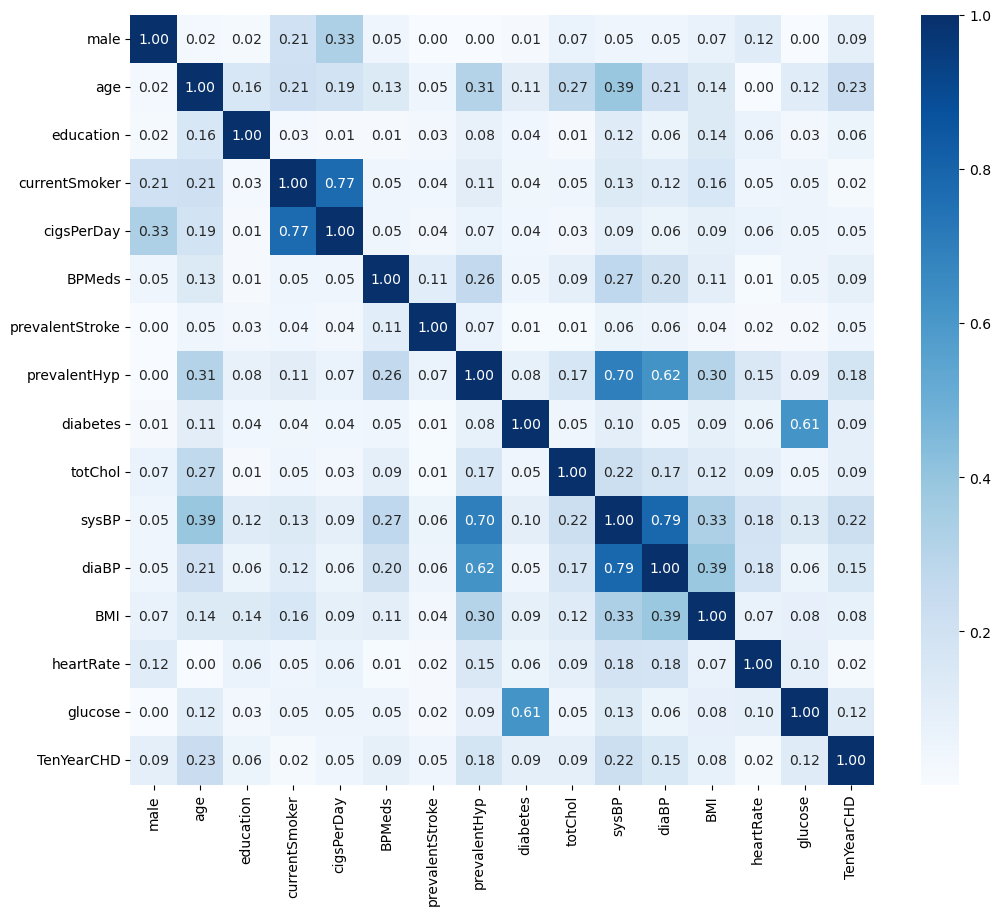

In [44]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df.corr().abs(),
    fmt='.2f',
    annot=True,
    cmap=plt.cm.Blues
)

### Step 5: Preparing Data

Perparing Features and Target

In [48]:
features = df.drop('TenYearCHD', axis=1)
target = df['TenYearCHD']

Balanced Data

In [81]:
ros = RandomOverSampler(random_state=42)

In [82]:
features, target = ros.fit_resample(features, target)

Split Data

In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

### Step 6: Building & Training Model

In [84]:
logreg = LogisticRegression()

In [85]:
stratified_kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [86]:
scores = cross_val_score(
        logreg,
        features,
        target,
        cv=stratified_kfold,
        scoring='accuracy',
        n_jobs=-1,
        error_score='raise'
    )

In [87]:
print(f'Model: {logreg.__class__.__name__}')
print(f'Scores: {scores}')
print(f'Mean Accuracy: {scores.mean():.3f}')

Model: LogisticRegression
Scores: [0.68573731 0.67526189 0.68306452 0.68145161 0.67741935]
Mean Accuracy: 0.681


In [88]:
logreg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Step 7: Evaluate Model

In [89]:
y_pred = logreg.predict(X_test)

In [90]:
accuracy = metrics.accuracy_score(y_test, y_pred)

In [91]:
print(f'Accuracy of the model is {100 * accuracy:.3f}%')

Accuracy of the model is 69.057%


In [92]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.69      0.69       622
           1       0.69      0.69      0.69       619

    accuracy                           0.69      1241
   macro avg       0.69      0.69      0.69      1241
weighted avg       0.69      0.69      0.69      1241



In [93]:
cm = metrics.confusion_matrix(y_test, y_pred)

<Axes: >

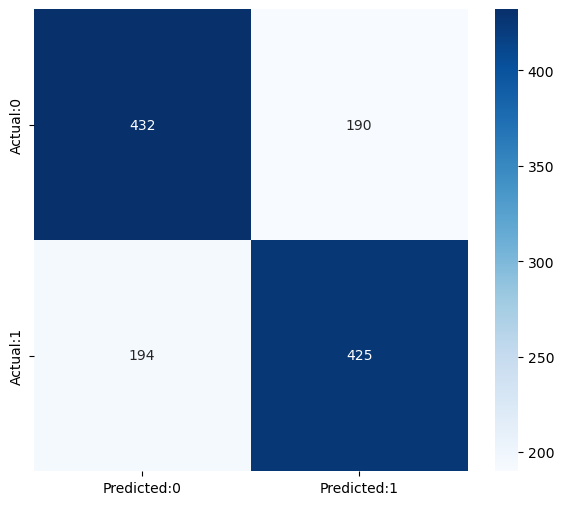

In [94]:
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    fmt='d',
    annot=True,
    cmap=plt.cm.Blues,
    xticklabels=['Predicted:0', 'Predicted:1'],
    yticklabels=['Actual:0', 'Actual:1'],
)